# Purple Team: Detection Validation & Residual-Risk Analytics

**Track:** Purple team / red–blue learning loop

Connect authorized emulation runs to telemetry coverage, alert quality, detection latency, and residual risk.

> **Safety boundary:** This lab is an offline analytical simulation. It contains no payloads, credential collection, exploitation steps, delivery infrastructure, or instructions for targeting real systems.

## Goal

Create a coverage matrix, benchmark detection models, check calibration, and rank validation gaps for joint red/blue remediation.


## Setup

The notebook uses deterministic synthetic data, an inspectable baseline, held-out evaluation, and figures designed for GitHub preview. Metrics demonstrate the workflow—not production effectiveness.


In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

BLUE = "#2F6B9A"
GOLD = "#D39A2C"
ORANGE = "#D66B3D"
OLIVE = "#71834A"
PINK = "#B05A7A"
SLATE = "#566573"
PALETTE = [BLUE, GOLD, ORANGE, OLIVE, PINK, SLATE]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 9,
})

def sigmoid(values):
    return 1.0 / (1.0 + np.exp(-np.clip(values, -30, 30)))

def model_metrics(labels, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def top_k_metrics(labels, probabilities, review_capacity):
    labels = np.asarray(labels)
    probabilities = np.asarray(probabilities)
    selected = np.argsort(probabilities)[-review_capacity:]
    predictions = np.zeros(len(probabilities), dtype=int)
    predictions[selected] = 1
    return {
        "average_precision": average_precision_score(labels, probabilities),
        "roc_auc": roc_auc_score(labels, probabilities),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "reviewed": int(predictions.sum()),
    }

def build_pipeline(numeric_features, categorical_features, estimator):
    transformer = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ])
    return Pipeline([("features", transformer), ("model", estimator)])

def feature_importance_table(pipeline):
    names = pipeline.named_steps["features"].get_feature_names_out()
    model = pipeline.named_steps["model"]
    values = (
        np.abs(model.coef_[0])
        if hasattr(model, "coef_")
        else model.feature_importances_
    )
    return (
        pd.DataFrame({"feature": names, "importance": values})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Steps

### 1. Generate red/blue validation evidence


In [2]:
tactics = np.array(["Access", "Execution", "Persistence", "Escalation", "Discovery", "Movement", "Collection", "Egress"])
control_layers = np.array(["Identity", "Endpoint", "Network", "Cloud", "Data"])
run_count = 2800
tactic = rng.choice(tactics, run_count)
control_layer = rng.choice(control_layers, run_count, p=[0.22, 0.25, 0.20, 0.18, 0.15])
telemetry_coverage = rng.beta(2.4, 1.8, run_count)
analytic_quality = rng.beta(2.1, 2.0, run_count)
rule_match = rng.binomial(1, 0.50, run_count)
ml_score = rng.beta(1.7, 2.4, run_count)
evidence_completeness = rng.beta(2.2, 1.9, run_count)
adversary_variation = rng.beta(1.8, 2.2, run_count)
control_strength = rng.beta(2.6, 1.7, run_count)
asset_impact = rng.integers(1, 6, run_count)
analyst_minutes = np.maximum(2, rng.normal(24 + 30 * (1 - evidence_completeness) + 12 * adversary_variation, 8)).round()

tactic_effect = pd.Series(tactic).map({
    "Access": 0.15, "Execution": 0.20, "Persistence": -0.15, "Escalation": 0.10,
    "Discovery": -0.25, "Movement": -0.05, "Collection": -0.20, "Egress": 0.18,
}).to_numpy()
detection_probability = sigmoid(
    -3.4 + 2.0 * telemetry_coverage + 1.8 * analytic_quality + 1.0 * rule_match
    + 1.7 * ml_score + 1.2 * evidence_completeness - 1.6 * adversary_variation
    + 0.6 * control_strength + tactic_effect
)
detected = rng.binomial(1, detection_probability)
alert_delay_minutes = np.where(
    detected.eq(1) if isinstance(detected, pd.Series) else detected == 1,
    np.maximum(1, rng.gamma(2.0, 12.0, run_count) * (1.25 - 0.55 * telemetry_coverage)),
    180.0,
)

validations = pd.DataFrame({
    "run_id": [f"VAL-{index:05d}" for index in range(run_count)],
    "tactic": tactic,
    "control_layer": control_layer,
    "telemetry_coverage": telemetry_coverage,
    "analytic_quality": analytic_quality,
    "rule_match": rule_match,
    "ml_score": ml_score,
    "evidence_completeness": evidence_completeness,
    "adversary_variation": adversary_variation,
    "control_strength": control_strength,
    "asset_impact": asset_impact,
    "analyst_minutes": analyst_minutes,
    "alert_delay_minutes": alert_delay_minutes,
    "detected": detected,
})
print(f"Synthetic validation runs: {len(validations):,}")
print(f"Detection rate: {validations['detected'].mean():.1%}")
print(f"Median detected-alert delay: {validations.loc[validations['detected'].eq(1), 'alert_delay_minutes'].median():.1f} minutes")
print(validations.head(4).round(3).to_string(index=False))


Synthetic validation runs: 2,800
Detection rate: 52.9%
Median detected-alert delay: 18.5 minutes
   run_id     tactic control_layer  telemetry_coverage  analytic_quality  rule_match  ml_score  evidence_completeness  adversary_variation  control_strength  asset_impact  analyst_minutes  alert_delay_minutes  detected
VAL-00000     Access      Endpoint               0.967             0.494           1     0.777                  0.772                0.776             0.482             4             47.0               17.748         1
VAL-00001 Collection      Identity               0.688             0.627           1     0.583                  0.556                0.201             0.393             1             48.0               39.177         1
VAL-00002   Movement          Data               0.649             0.724           1     0.724                  0.133                0.326             0.784             4             48.0               30.634         1
VAL-00003 Escalation      E

### 2. Score residual risk and build a joint remediation queue


In [3]:
validations["baseline_detection_score"] = np.clip(
    0.23 * validations["telemetry_coverage"]
    + 0.20 * validations["analytic_quality"]
    + 0.13 * validations["rule_match"]
    + 0.16 * validations["ml_score"]
    + 0.13 * validations["evidence_completeness"]
    - 0.13 * validations["adversary_variation"]
    + 0.08 * validations["control_strength"], 0, 1,
)
validations["residual_risk"] = (
    validations["asset_impact"]
    * (1 - validations["baseline_detection_score"])
    * (1 + 0.7 * validations["adversary_variation"])
)
baseline_result = model_metrics(validations["detected"], validations["baseline_detection_score"], 0.5)
coverage_summary = validations.groupby(["tactic", "control_layer"]).agg(
    runs=("run_id", "count"),
    detection_rate=("detected", "mean"),
    median_delay_or_censor=("alert_delay_minutes", "median"),
    mean_residual_risk=("residual_risk", "mean"),
).reset_index()
remediation_queue = coverage_summary[coverage_summary["runs"] >= 30].sort_values(
    ["mean_residual_risk", "detection_rate"], ascending=[False, True]
).head(12)
print("Baseline detection quality:")
print(pd.Series(baseline_result).round(3).to_string())
print("\nJoint remediation queue:")
print(remediation_queue.round(3).to_string(index=False))


Baseline detection quality:
average_precision      0.777
roc_auc                0.759
precision              0.826
recall                 0.404
f1                     0.542
reviewed             724.000

Joint remediation queue:
     tactic control_layer  runs  detection_rate  median_delay_or_censor  mean_residual_risk
  Execution      Identity    75           0.507                  61.533               2.523
     Egress         Cloud    55           0.491                 180.000               2.516
   Movement         Cloud    57           0.456                 180.000               2.494
 Escalation      Endpoint    94           0.564                  46.454               2.493
  Discovery      Identity    84           0.524                  66.985               2.489
Persistence         Cloud    71           0.366                 180.000               2.480
  Discovery       Network    79           0.544                  35.565               2.461
  Execution      Endpoint   115     

## Visual Insights & ML Extension

The coverage matrix locates gaps, the calibration view challenges probability quality, and the held-out benchmark plus feature importance indicate where the learning loop should focus.


                   average_precision  roc_auc  precision  recall     f1  reviewed  brier
model                                                                                   
Coverage baseline              0.758    0.745      0.817   0.410  0.546       208  0.226
Logistic                       0.760    0.752      0.707   0.680  0.693       399  0.202
Random forest                  0.737    0.732      0.686   0.672  0.679       407  0.211

Decision insight: remediate high-impact tactic/layer gaps, rerun the same validation, and measure whether coverage and latency improve.


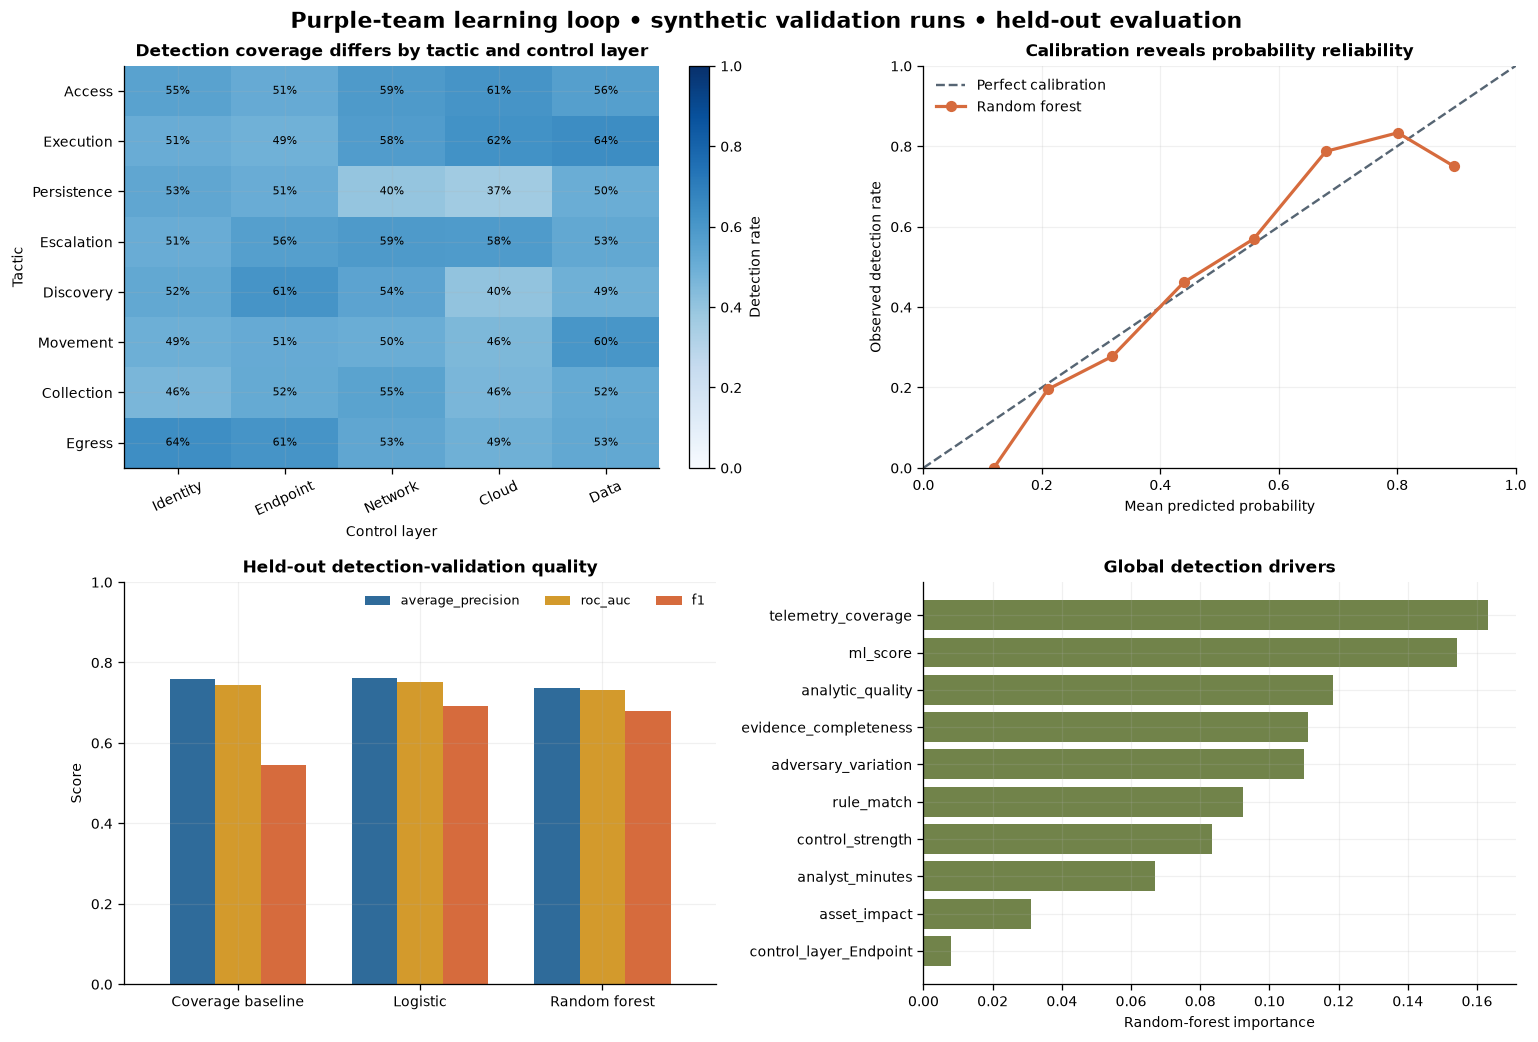

In [4]:
feature_columns = [
    "tactic", "control_layer", "telemetry_coverage", "analytic_quality", "rule_match",
    "ml_score", "evidence_completeness", "adversary_variation", "control_strength",
    "asset_impact", "analyst_minutes",
]
categorical_features = ["tactic", "control_layer"]
numeric_features = [column for column in feature_columns if column not in categorical_features]
train_index, test_index = train_test_split(
    np.arange(len(validations)), test_size=0.28, random_state=SEED,
    stratify=validations["detected"],
)
X_train = validations.loc[train_index, feature_columns]
X_test = validations.loc[test_index, feature_columns]
y_train = validations.loc[train_index, "detected"]
y_test = validations.loc[test_index, "detected"]

logistic = build_pipeline(numeric_features, categorical_features,
                          LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED))
forest = build_pipeline(numeric_features, categorical_features,
                        RandomForestClassifier(n_estimators=280, min_samples_leaf=7, class_weight="balanced", random_state=SEED))
logistic.fit(X_train, y_train)
forest.fit(X_train, y_train)
probabilities = {
    "Coverage baseline": validations.loc[test_index, "baseline_detection_score"].to_numpy(),
    "Logistic": logistic.predict_proba(X_test)[:, 1],
    "Random forest": forest.predict_proba(X_test)[:, 1],
}
metrics_table = pd.DataFrame([
    {"model": name, **model_metrics(y_test, values, 0.5), "brier": brier_score_loss(y_test, values)}
    for name, values in probabilities.items()
]).set_index("model")
importance = feature_importance_table(forest).head(10).sort_values("importance")

coverage_matrix = validations.pivot_table(
    index="tactic", columns="control_layer", values="detected", aggfunc="mean"
).reindex(index=tactics, columns=control_layers)
calibration_probability = probabilities["Random forest"]
calibration_frame = pd.DataFrame({"probability": calibration_probability, "label": y_test.to_numpy()})
calibration_frame["bin"] = pd.cut(calibration_frame["probability"], bins=np.linspace(0, 1, 9), include_lowest=True)
calibration = calibration_frame.groupby("bin", observed=False).agg(
    mean_probability=("probability", "mean"), observed_rate=("label", "mean"), count=("label", "size")
).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2))
image = axes[0, 0].imshow(coverage_matrix.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
axes[0, 0].set(title="Detection coverage differs by tactic and control layer", xlabel="Control layer", ylabel="Tactic",
               xticks=range(len(control_layers)), xticklabels=control_layers,
               yticks=range(len(tactics)), yticklabels=tactics)
axes[0, 0].tick_params(axis="x", rotation=25)
for row in range(len(tactics)):
    for column in range(len(control_layers)):
        axes[0, 0].text(column, row, f"{coverage_matrix.iloc[row, column]:.0%}", ha="center", va="center", fontsize=7)
fig.colorbar(image, ax=axes[0, 0], fraction=0.046, label="Detection rate")

axes[0, 1].plot([0, 1], [0, 1], color=SLATE, linestyle="--", label="Perfect calibration")
axes[0, 1].plot(calibration["mean_probability"], calibration["observed_rate"], color=ORANGE, marker="o", linewidth=2,
                label="Random forest")
axes[0, 1].set(title="Calibration reveals probability reliability", xlabel="Mean predicted probability", ylabel="Observed detection rate",
               xlim=(0, 1), ylim=(0, 1))
axes[0, 1].legend(frameon=False)

metrics_table[["average_precision", "roc_auc", "f1"]].plot(
    kind="bar", ax=axes[1, 0], color=[BLUE, GOLD, ORANGE], width=0.75
)
axes[1, 0].set(title="Held-out detection-validation quality", xlabel="", ylabel="Score", ylim=(0, 1))
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].legend(frameon=False, ncol=3, fontsize=8)

axes[1, 1].barh(importance["feature"].str.replace("numeric__", "").str.replace("categorical__", ""),
                importance["importance"], color=OLIVE)
axes[1, 1].set(title="Global detection drivers", xlabel="Random-forest importance")
fig.suptitle("Purple-team learning loop • synthetic validation runs • held-out evaluation", fontsize=14, fontweight="bold")
fig.tight_layout()

print(metrics_table.round(3).to_string())
print("\nDecision insight: remediate high-impact tactic/layer gaps, rerun the same validation, and measure whether coverage and latency improve.")


## Checks

Assertions cover run grain, bounds, coverage completeness, holdout separation, calibration bins, and metric validity.


In [5]:
assert validations["run_id"].is_unique
assert validations.isna().sum().sum() == 0
assert validations["baseline_detection_score"].between(0, 1).all()
assert validations["residual_risk"].ge(0).all()
assert coverage_matrix.notna().all().all()
assert set(train_index).isdisjoint(set(test_index))
assert calibration["count"].sum() == len(test_index)
assert metrics_table[["average_precision", "roc_auc", "precision", "recall", "f1", "brier"]].apply(lambda column: column.between(0, 1).all()).all()
print("All checks passed: unique runs, complete coverage matrix, clean holdout, valid calibration bins, and bounded metrics.")


All checks passed: unique runs, complete coverage matrix, clean holdout, valid calibration bins, and bounded metrics.


## Next Steps

- Map each authorized emulation to an expected data source, analytic, alert, owner, and response objective.
- Split validation by campaign/time for production evaluation and retain failed runs instead of reporting only successes.
- Add confidence intervals, calibration monitoring, and explicit analyst-capacity costs.
- Use the remediation queue as a joint learning backlog; rerun identical safe tests after each detection change.
